## Postprocessing and Analysis of Monte Carlo Results

In this notebook, we analyze the Monte Carlo simulation results obtained from the three reconstruction strategies:

* DG-based SIAC filtering applied post-FBP  (`dg`)
* Fourier-domain SIAC filtering applied post-FBP (`fourier`)
* Detector-domain SIAC filtering applied pre-FBP (`detector`)

The raw simulation outputs have been precomputed and stored as CSV files. Each row corresponds to a single Monte Carlo realization for a given noise level and parameter configuration, including:

* reconstruction parameters (e.g. polynomial degree (p), number of moments, B-spline order),
* noise level and random seed,
* quantitative evaluation metrics:

  * relative ($L^2$) error,
  * masked relative ($L^2$) error,
  * gradient-weighted SSIM,
  * SSIM.

The purpose of this notebook is to:

1. Load and unify the results from all methods into a single dataset.
2. Compute summary statistics (mean, standard deviation, etc.) over Monte Carlo repetitions.
3. Identify optimal parameter configurations for each method as a function of noise level.
4. Compare reconstruction performance across methods using multiple metrics.
5. Visualize trends, parameter sensitivity, and robustness.

This separation between simulation and analysis ensures reproducibility, simplifies experimentation, and enables flexible exploration of the results without rerunning computationally expensive simulations.


In [18]:
import numpy as np
import pandas as pd

import sys
sys.path.append("../..")

from src.metrics import(
    summarize_mc_results, 
    select_best_by_noise, 
    select_fixed_params_from_reference_noise, 
    filter_summary_by_fixed_params, 
    display_fixed_params, 
    make_method_variant
)
from src.plotting_helpers import (
    display_best_params, 
    plot_mc_metric, 
    plot_selected_param_vs_noise, 
    plot_param_heatmap, 
    compare_fixed_vs_retuned
)

In [19]:
# Read result files
results_dg = pd.read_csv("results_dg.csv")
results_fourier = pd.read_csv("results_fourier.csv")
results_detector = pd.read_csv("results_detector.csv")
results_ramlak = pd.read_csv("results_ramlak.csv")
results_hann = pd.read_csv("results_hann.csv")

# Columns you want available everywhere
common_cols = [
    "method", "noise_level", "rep", "seed",
    "p", "moments", "BSorder",
    "rel_l2_err", "masked_rel_l2_err", "gw_ssim", "ssim"
]

# Helper: add missing columns as NaN, then reorder
def align_columns(df, common_cols):
    df = df.copy()
    for col in common_cols:
        if col not in df.columns:
            df[col] = np.nan
    return df[common_cols]

results_dg = align_columns(results_dg, common_cols)
results_fourier = align_columns(results_fourier, common_cols)
results_detector = align_columns(results_detector, common_cols)
results_ramlak = align_columns(results_ramlak, common_cols)
results_hann = align_columns(results_hann, common_cols)

# Combine into one dataframe
results_all = pd.concat(
    [
        results_dg,
        results_fourier,
        results_detector,
        results_ramlak,
        results_hann,
    ],
    ignore_index=True
)

# Adjust moments: stored value -> true reproduced moments (+1)
if "moments" in results_all.columns:
    mask = results_all["moments"].notna()
    results_all.loc[mask, "moments"] = results_all.loc[mask, "moments"] + 1

# Adjust these names to match exactly what appears in results_all["method"]
family_map = {
    "fbp_ramlak": "FBP",
    "fbp_hann": "FBP",
    "post_recon_dg_siac": "SIAC",
    "post_recon_fourier_siac": "SIAC",
    "pre_recon_detector_siac": "SIAC",
}

results_all["family"] = results_all["method"].map(family_map)

results_all["method_variant"] = results_all.apply(make_method_variant, axis=1)

# Quick sanity checks
print("Shape of combined dataframe:", results_all.shape)

print("\nMethods:")
print(results_all["method"].value_counts())

print("\nUnique method names:")
print(results_all["method"].unique())

print("\nMissing values:")
print(results_all.isna().sum())

print("\nFamily counts:")
print(results_all["family"].value_counts(dropna=False))

Shape of combined dataframe: (33320, 13)

Methods:
method
pre_recon_detector_siac    15120
post_recon_fourier_siac     9240
post_recon_dg_siac          8400
fbp_ramlak                   280
fbp_hann                     280
Name: count, dtype: int64

Unique method names:
['post_recon_dg_siac' 'post_recon_fourier_siac' 'pre_recon_detector_siac'
 'fbp_ramlak' 'fbp_hann']

Missing values:
method                   0
noise_level              0
rep                      0
seed                     0
p                    24920
moments                560
BSorder                560
rel_l2_err               0
masked_rel_l2_err        0
gw_ssim                  0
ssim                     0
family                   0
method_variant           0
dtype: int64

Family counts:
family
SIAC    32760
FBP       560
Name: count, dtype: int64


In [20]:
summary_all = summarize_mc_results(
    results_all,
    metric_cols=["rel_l2_err", "masked_rel_l2_err", "gw_ssim", "ssim"]
)

summary_all.head(30)


,family,method,method_variant,noise_level,p,moments,BSorder,rel_l2_err_mean,rel_l2_err_std,rel_l2_err_min,...,masked_rel_l2_err_min,masked_rel_l2_err_max,gw_ssim_mean,gw_ssim_std,gw_ssim_min,gw_ssim_max,ssim_mean,ssim_std,ssim_min,ssim_max
0,FBP,fbp_hann,fbp_hann,0.01,NaN,NaN,NaN,0.282046,0.000155,0.281778,...,0.265682,0.266289,0.897556,0.000191,0.897254,0.897833,0.662474,0.001077,0.661206,0.665227
1,FBP,fbp_hann,fbp_hann,0.02,NaN,NaN,NaN,0.285947,0.000304,0.285439,...,0.267550,0.268817,0.895193,0.000380,0.894564,0.895754,0.626948,0.001749,0.625132,0.631072
2,FBP,fbp_hann,fbp_hann,0.03,NaN,NaN,NaN,0.292345,0.000449,0.291631,...,0.270813,0.272789,0.891443,0.000570,0.890469,0.892274,0.579809,0.002041,0.577810,0.583962
3,FBP,fbp_hann,fbp_hann,0.04,NaN,NaN,NaN,0.301081,0.000591,0.300197,...,0.275425,0.278145,0.886506,0.000758,0.885175,0.887574,0.530524,0.002116,0.527308,0.533972
4,FBP,fbp_hann,fbp_hann,0.05,NaN,NaN,NaN,0.311959,0.000732,0.310914,...,0.281319,0.284805,0.880593,0.000942,0.878897,0.881850,0.484672,0.002110,0.480622,0.487852
5,FBP,fbp_hann,fbp_hann,0.06,NaN,NaN,NaN,0.324763,0.000876,0.323510,...,0.288417,0.292681,0.873901,0.001120,0.871835,0.875380,0.444446,0.002083,0.439929,0.448182
6,FBP,fbp_hann,fbp_hann,0.07,NaN,NaN,NaN,0.339276,0.001021,0.337823,...,0.296632,0.301678,0.866601,0.001292,0.864160,0.868338,0.410103,0.002053,0.405392,0.414142
7,FBP,fbp_hann,fbp_hann,0.08,NaN,NaN,NaN,0.355288,0.001170,0.353644,...,0.305874,0.311699,0.858837,0.001459,0.856016,0.860809,0.381059,0.002020,0.376336,0.385219
8,FBP,fbp_hann,fbp_hann,0.09,NaN,NaN,NaN,0.372606,0.001323,0.370780,...,0.316053,0.322647,0.850725,0.001621,0.847521,0.852908,0.356485,0.001987,0.351861,0.360646
9,FBP,fbp_hann,fbp_hann,0.10,NaN,NaN,NaN,0.391056,0.001478,0.389057,...,0.327082,0.334433,0.842359,0.001781,0.838770,0.844729,0.335572,0.001956,0.331110,0.339658


**NOTE**: 

The **masked relative $L^2$ error** and **gradient-weighted SSIM** are the primary metrics of interest in this study. 

The standard relative $L^2$ error and SSIM can be biased toward overly smooth reconstructions, as they are computed over the entire domain, including large regions of zero-valued background. This can skew the results in favor of methods that suppress variation, rather than accurately reconstruct relevant features.

By contrast, the masked and gradient-weighted metrics better reflect the **quality of the reconstructed phantom itself**, which is the main objective of this analysis.

### Best Result for each Noise Level

In this section, we visualize the **best achievable performance** at each noise level for every method and metric.

For a fixed noise level, we:
* consider all parameter configurations for a given method,
* extract the **optimal value** of the chosen metric (e.g. minimum relative $L^2$ error or maximum SSIM),
* and plot this best value as a function of the noise level.

This corresponds to **optimal parameter tuning** at each noise level, meaning that the selected parameters (e.g. moments, B-spline order) may vary with the noise level.

,family,method_variant,method,noise_level,p,moments,BSorder,masked_rel_l2_err_mean,masked_rel_l2_err_std
0,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.01,1.0,7.0,1.0,0.269537,0.000170
1,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.02,1.0,7.0,1.0,0.272974,0.000325
2,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.03,1.0,7.0,1.0,0.278642,0.000480
3,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.04,1.0,7.0,1.0,0.286410,0.000651
4,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.05,1.0,7.0,1.0,0.296113,0.000846
5,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.06,1.0,7.0,1.0,0.307568,0.001071
6,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.07,1.0,7.0,2.0,0.319970,0.001125
7,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.08,1.0,7.0,2.0,0.330192,0.001348
8,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.09,1.0,5.0,2.0,0.340931,0.001473
9,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.10,1.0,5.0,2.0,0.351748,0.001704


(<Figure size 700x450 with 1 Axes>,
 <Axes: xlabel='Noise level', ylabel='Masked relative $L^2$ error'>)

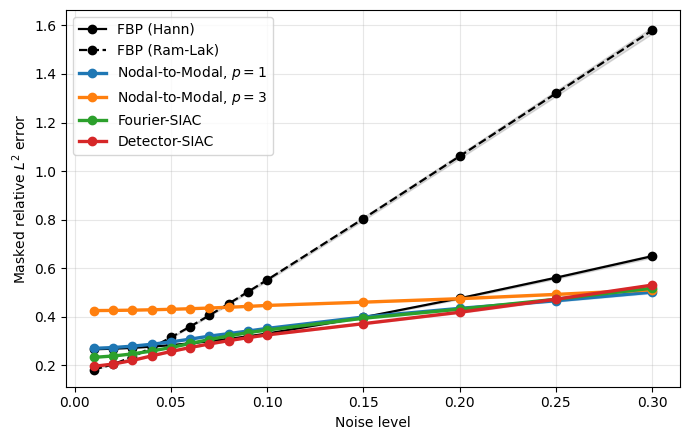

In [21]:
best_masked_rel_l2 = select_best_by_noise(
    summary_all,
    metric="masked_rel_l2_err",
    method_col="method_variant",
    minimize=True,
)

display_best_params(best_masked_rel_l2, metric="masked_rel_l2_err")

plot_mc_metric(
    best_masked_rel_l2,
    metric="masked_rel_l2_err",
    # title="Best masked relative $L^2$ error vs noise level",
    method_col="method_variant",
    ylabel="Masked relative $L^2$ error",
    style_cols=[],
    save_path="figures/MC_best_masked_rel_l2_vs_noise.pdf"
)

,family,method_variant,method,noise_level,p,moments,BSorder,gw_ssim_mean,gw_ssim_std
0,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.01,1.0,7.0,1.0,0.901747,0.000207
1,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.02,1.0,7.0,1.0,0.898158,0.000416
2,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.03,1.0,7.0,1.0,0.892575,0.000624
3,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.04,1.0,7.0,1.0,0.885400,0.000826
4,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.05,1.0,7.0,1.0,0.877017,0.001024
5,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.06,1.0,7.0,1.0,0.867750,0.001219
6,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.07,1.0,7.0,1.0,0.857857,0.001414
7,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.08,1.0,7.0,1.0,0.847532,0.001607
8,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.09,1.0,7.0,2.0,0.838442,0.001828
9,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.10,1.0,7.0,2.0,0.829532,0.002021


(<Figure size 700x450 with 1 Axes>,
 <Axes: xlabel='Noise level', ylabel='Gradient-weighted SSIM'>)

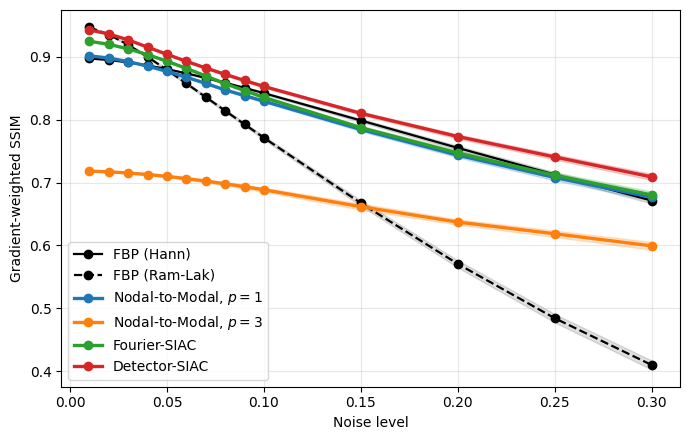

In [22]:
best_gw_ssim = select_best_by_noise(
    summary_all,
    metric="gw_ssim",
    method_col="method_variant",
    minimize=False,
)

display_best_params(best_gw_ssim, metric="gw_ssim")

plot_mc_metric(
    best_gw_ssim,
    metric="gw_ssim",
    # title="Best gradient-weighted SSIM vs noise level",
    method_col="method_variant",
    ylabel="Gradient-weighted SSIM",
    style_cols=[],
    save_path="figures/MC_best_gwssim_vs_noise.pdf"
)

,family,method_variant,method,noise_level,p,moments,BSorder,rel_l2_err_mean,rel_l2_err_std
0,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.01,1.0,7.0,1.0,0.285909,0.000245
1,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.02,1.0,7.0,1.0,0.292060,0.000482
2,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.03,1.0,7.0,1.0,0.302055,0.000722
3,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.04,1.0,5.0,1.0,0.315484,0.000912
4,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.05,1.0,7.0,2.0,0.327647,0.000920
5,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.06,1.0,5.0,2.0,0.340998,0.001035
6,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.07,1.0,3.0,2.0,0.354455,0.001073
7,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.08,1.0,3.0,2.0,0.366923,0.001250
8,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.09,1.0,3.0,2.0,0.380563,0.001436
9,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.10,1.0,3.0,3.0,0.392541,0.001410


(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Best relative $L^2$ error vs noise level'}, xlabel='Noise level', ylabel='Relative $L^2$ error'>)

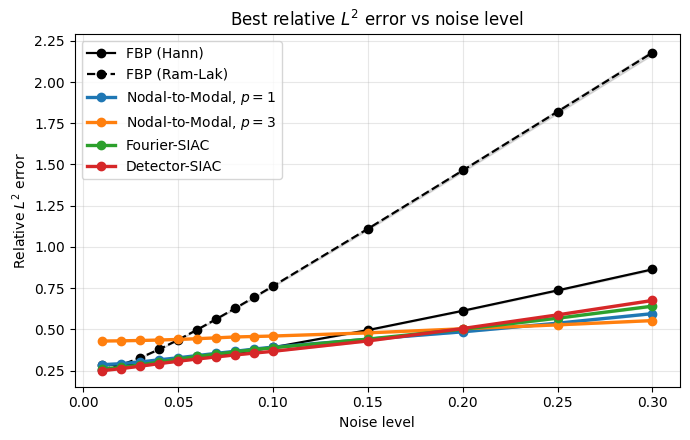

In [23]:
best_rel_l2 = select_best_by_noise(
    summary_all,
    metric="rel_l2_err",
    method_col="method_variant",
    minimize=True,
)

display_best_params(best_rel_l2, metric="rel_l2_err")

plot_mc_metric(
    best_rel_l2,
    metric="rel_l2_err",
    title="Best relative $L^2$ error vs noise level",
    method_col="method_variant",
    ylabel="Relative $L^2$ error",
    style_cols=[],
)

,family,method_variant,method,noise_level,p,moments,BSorder,ssim_mean,ssim_std
0,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.01,1.0,3.0,5.0,0.776237,0.001856
1,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.02,1.0,3.0,5.0,0.752732,0.003086
2,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.03,1.0,3.0,5.0,0.717631,0.003680
3,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.04,1.0,3.0,5.0,0.675729,0.003923
4,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.05,1.0,3.0,5.0,0.631420,0.004053
5,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.06,1.0,3.0,5.0,0.587876,0.004151
6,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.07,1.0,3.0,5.0,0.546987,0.004208
7,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.08,1.0,3.0,5.0,0.509658,0.004209
8,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.09,1.0,3.0,5.0,0.476151,0.004152
9,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,0.10,1.0,3.0,5.0,0.446355,0.004051


(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Best SSIM vs noise level'}, xlabel='Noise level', ylabel='SSIM'>)

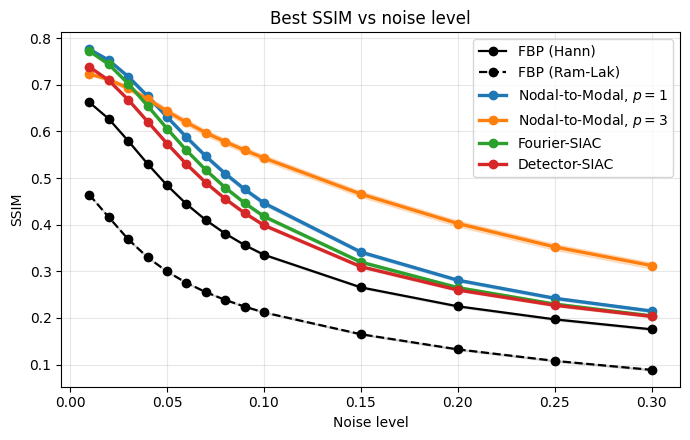

In [24]:
best_ssim = select_best_by_noise(
    summary_all,
    metric="ssim",
    method_col="method_variant",
    minimize=False,
)

display_best_params(best_ssim, metric="ssim")

plot_mc_metric(
    best_ssim,
    metric="ssim",
    title="Best SSIM vs noise level",
    method_col="method_variant",
    ylabel="SSIM",
    style_cols=[],
)

### Best Parameter setup vs Noise Level

In this section, we examine how the **optimal parameter configuration** evolves as the noise level increases.

For each noise level, we:

* identify the parameter setup that yields the best performance (according to the chosen metric),
* and track how this optimum is achieved through changes in:
    * the number of reproduced moments, and
    * the smoothness of the kernel (controlled by the B-spline order).

This provides insight into how the trade-off between accuracy (via moment reproduction) and smoothness (which suppresses noise) evolves as the noise level increases.

(<Figure size 700x450 with 1 Axes>,
 <Axes: xlabel='Noise level', ylabel='Basis degree'>)

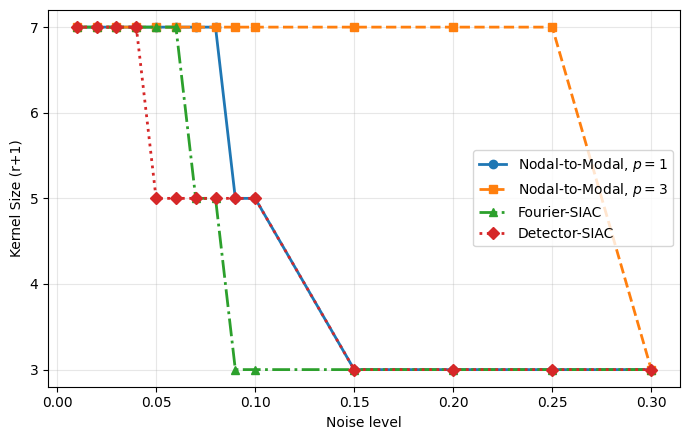

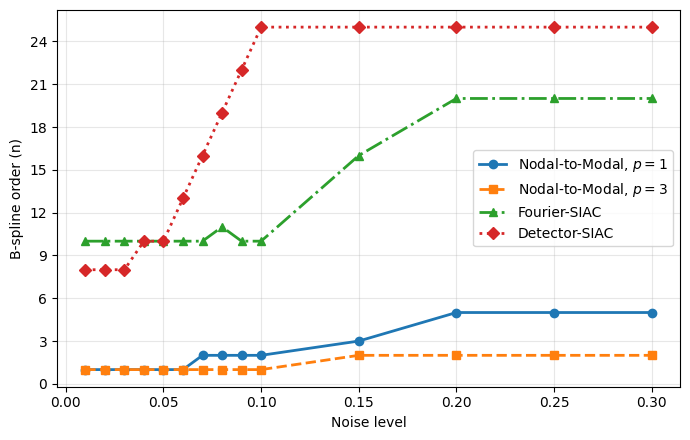

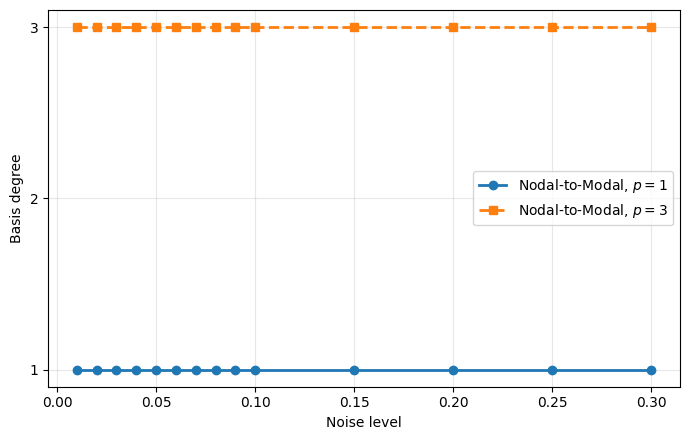

In [25]:
plot_selected_param_vs_noise(
    best_masked_rel_l2,
    param="moments",
    # title="Selected moments vs noise level",
    method_col="method_variant",
    ylabel="Kernel Size (r+1)",
    save_path="figures/params_moments_vs_noise.pdf"
)

plot_selected_param_vs_noise(
    best_masked_rel_l2,
    param="BSorder",
    # title="Selected B-spline order vs noise level",
    method_col="method_variant",
    ylabel="B-spline order (n)",
    save_path="figures/params_BSorder_vs_noise.pdf"
)

plot_selected_param_vs_noise(
    best_masked_rel_l2[best_masked_rel_l2["method"] == "post_recon_dg_siac"],
    param="p",
    method_col="method_variant",
    ylabel="Basis degree",
)

### Parameter Heatmaps

In this section, we visually examine the performance of different parameter configurations (moments and B-spline orders) across varying noise levels.

We consider three representative cases:
* low noise ($3\%$ relative noise)
* moderate noise ($10\%$ relative noise)
* high noise ($30\%$ relative noise)

(<Figure size 600x450 with 2 Axes>,
 <Axes: title={'center': 'DG (p=1): masked relative $L^2$ error, noise = 0.30'}, xlabel='BSorder', ylabel='moments'>)

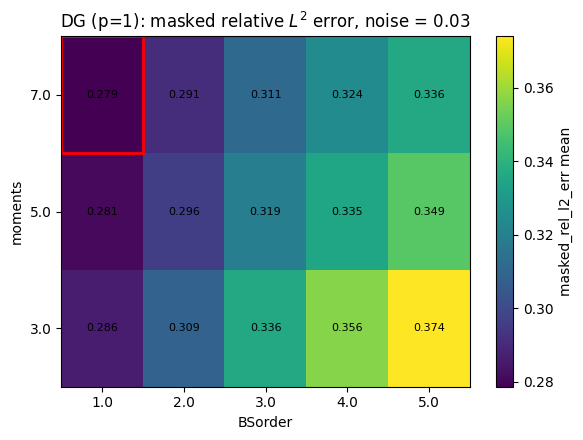

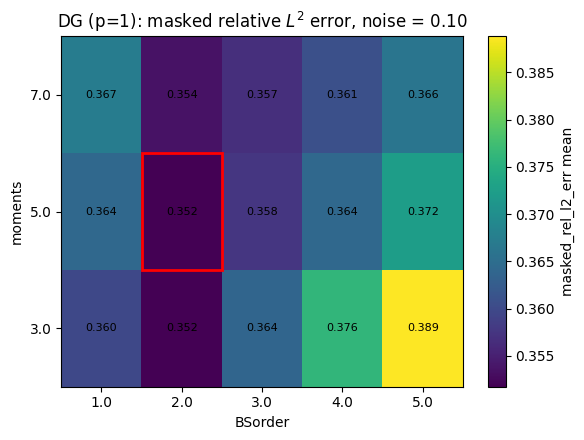

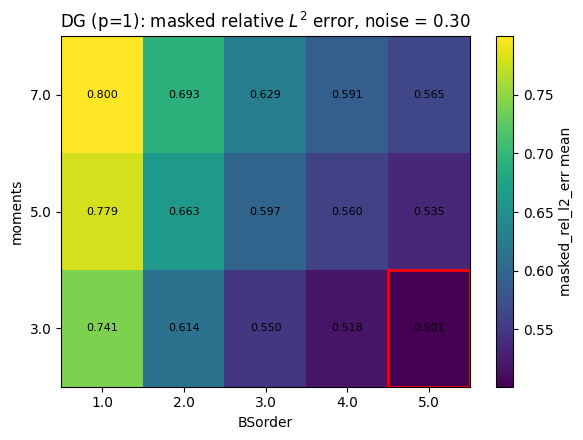

In [26]:
plot_param_heatmap(
    summary_all,
    method="post_recon_dg_siac",
    metric="masked_rel_l2_err",
    noise_level=0.03,
    fixed_filters={"p": 1},
    title="DG (p=1): masked relative $L^2$ error, noise = 0.03",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="post_recon_dg_siac",
    metric="masked_rel_l2_err",
    noise_level=0.10,
    fixed_filters={"p": 1},
    title="DG (p=1): masked relative $L^2$ error, noise = 0.10",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="post_recon_dg_siac",
    metric="masked_rel_l2_err",
    noise_level=0.30,
    fixed_filters={"p": 1},
    title="DG (p=1): masked relative $L^2$ error, noise = 0.30",
    minimize=True
)

In [27]:
# plot_param_heatmap(
#     summary_all,
#     method="post_recon_dg_siac",
#     metric="masked_rel_l2_err",
#     noise_level=0.03,
#     fixed_filters={"p": 3},
#     title="DG (p=3): masked relative $L^2$ error, noise = 0.03",
#     minimize=True
# )

# plot_param_heatmap(
#     summary_all,
#     method="post_recon_dg_siac",
#     metric="masked_rel_l2_err",
#     noise_level=0.10,
#     fixed_filters={"p": 3},
#     title="DG (p=3): masked relative $L^2$ error, noise = 0.10",
#     minimize=True
# )

# plot_param_heatmap(
#     summary_all,
#     method="post_recon_dg_siac",
#     metric="masked_rel_l2_err",
#     noise_level=0.30,
#     fixed_filters={"p": 3},
#     title="DG (p=3): masked relative $L^2$ error, noise = 0.30",
#     minimize=True
# )

(<Figure size 600x450 with 2 Axes>,
 <Axes: title={'center': 'Fourier: masked relative $L^2$ error, noise = 0.30'}, xlabel='BSorder', ylabel='moments'>)

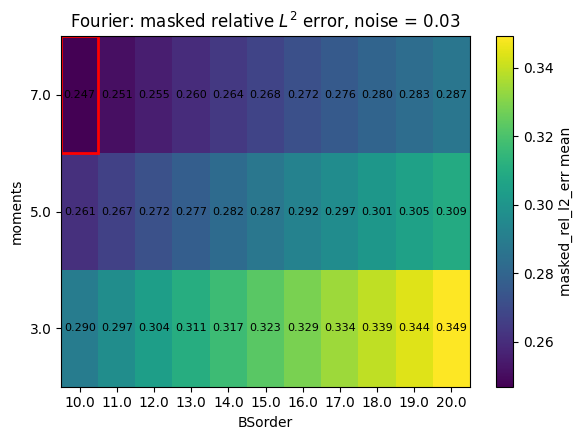

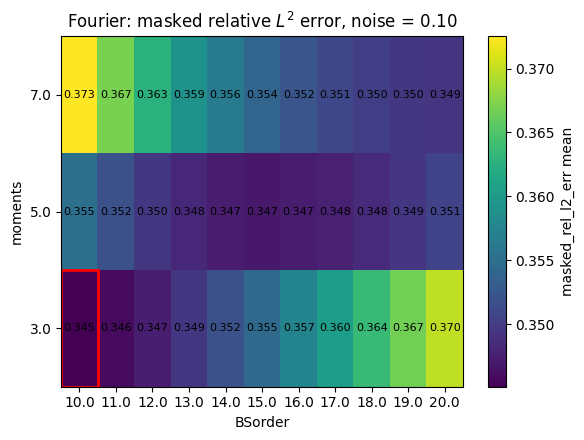

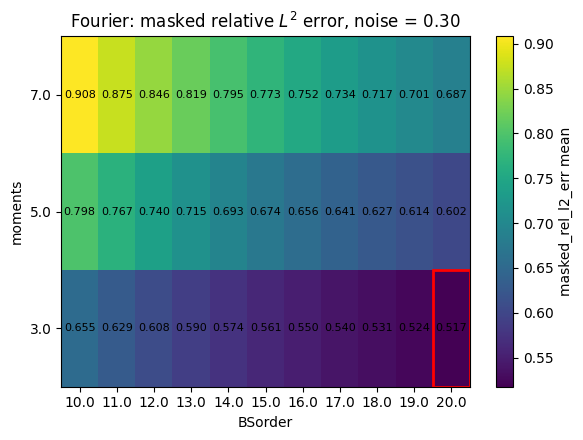

In [28]:
plot_param_heatmap(
    summary_all,
    method="post_recon_fourier_siac",
    metric="masked_rel_l2_err",
    noise_level=0.03,
    title="Fourier: masked relative $L^2$ error, noise = 0.03",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="post_recon_fourier_siac",
    metric="masked_rel_l2_err",
    noise_level=0.10,
    title="Fourier: masked relative $L^2$ error, noise = 0.10",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="post_recon_fourier_siac",
    metric="masked_rel_l2_err",
    noise_level=0.30,
    title="Fourier: masked relative $L^2$ error, noise = 0.30",
    minimize=True
)

(<Figure size 600x450 with 2 Axes>,
 <Axes: title={'center': 'Detector: masked relative $L^2$ error, noise = 0.30'}, xlabel='BSorder', ylabel='moments'>)

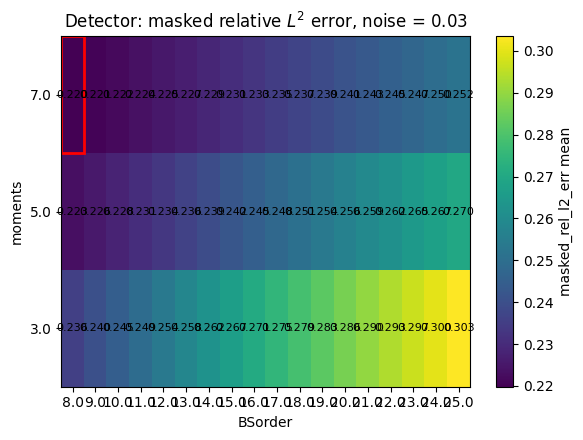

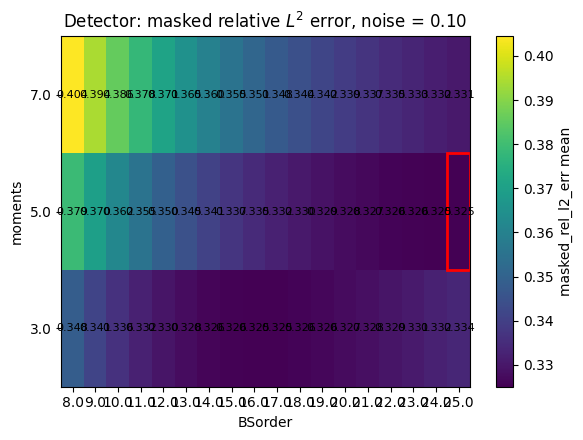

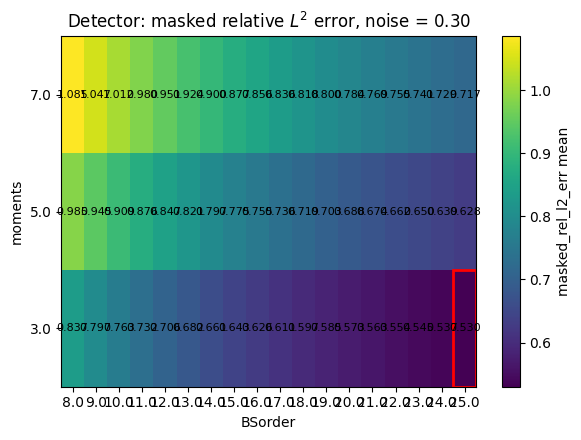

In [29]:
plot_param_heatmap(
    summary_all,
    method="pre_recon_detector_siac",
    metric="masked_rel_l2_err",
    noise_level=0.03,
    title="Detector: masked relative $L^2$ error, noise = 0.03",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="pre_recon_detector_siac",
    metric="masked_rel_l2_err",
    noise_level=0.10,
    title="Detector: masked relative $L^2$ error, noise = 0.10",
    minimize=True
)
plot_param_heatmap(
    summary_all,
    method="pre_recon_detector_siac",
    metric="masked_rel_l2_err",
    noise_level=0.30,
    title="Detector: masked relative $L^2$ error, noise = 0.30",
    minimize=True
)

### Fixed Parameter Setup Performance Across Noise Levels

In this section, we analyze the performance of a **fixed parameter configuration** across varying noise levels.

We select the parameter setup that is **optimal at $10\%$ relative noise**, as determined by one of our primary metrics (the **masked relative $L^2$ error**).This fixed configuration is then evaluated across all noise levels for each method and compared against the reference solutions, allowing us to assess how **robust** each method is to changes in noise.

We then compare these results with the corresponding **optimally tuned parameter setups at each noise level**, in order to quantify the performance gap between:
* a **fixed (noise-independent) configuration**, and
* **noise-dependent optimal tuning**.

This comparison provides insight into the trade-off between **robustness and adaptability** in parameter selection.

In [30]:
fixed_params_10_masked = select_fixed_params_from_reference_noise(
    summary_all,
    metric="masked_rel_l2_err",
    reference_noise=0.10,
    method_col="method_variant",
    minimize=True,
)

display_fixed_params(
    fixed_params_10_masked,
    metric="masked_rel_l2_err",
)

fixed_curves_10_masked = filter_summary_by_fixed_params(
    summary_all,
    fixed_params_10_masked,
    method_col="method_variant",
)

,family,method_variant,method,p,moments,BSorder,masked_rel_l2_err_mean,masked_rel_l2_err_std
0,SIAC,post_recon_dg_siac_p1,post_recon_dg_siac,1.0,5.0,2.0,0.351748,0.001704
1,SIAC,post_recon_dg_siac_p3,post_recon_dg_siac,3.0,7.0,1.0,0.446463,0.001635
2,SIAC,post_recon_fourier_siac,post_recon_fourier_siac,NaN,3.0,10.0,0.345094,0.001833
3,SIAC,pre_recon_detector_siac,pre_recon_detector_siac,NaN,5.0,25.0,0.325073,0.001789


(<Figure size 700x450 with 1 Axes>,
 <Axes: xlabel='Noise level', ylabel='Masked relative $L^2$ error'>)

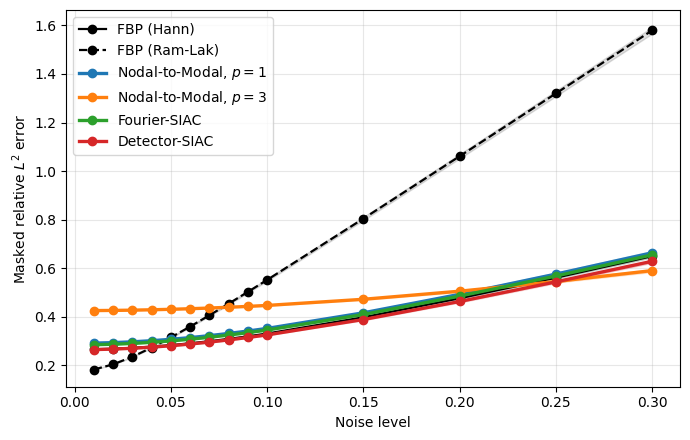

In [31]:
plot_mc_metric(
    fixed_curves_10_masked,
    metric="masked_rel_l2_err",
    # title="Fixed parameters chosen at 10% noise: masked relative $L^2$ vs noise level",
    method_col="method_variant",
    ylabel="Masked relative $L^2$ error",
    style_cols=[],
    save_path="figures/MC_fixedparams_masked_rel_l2_vs_noise.pdf"
)

(<Figure size 700x450 with 1 Axes>,
 <Axes: title={'center': 'Fixed parameters chosen at 10% noise: SSIM vs noise level'}, xlabel='Noise level', ylabel='SSIM'>)

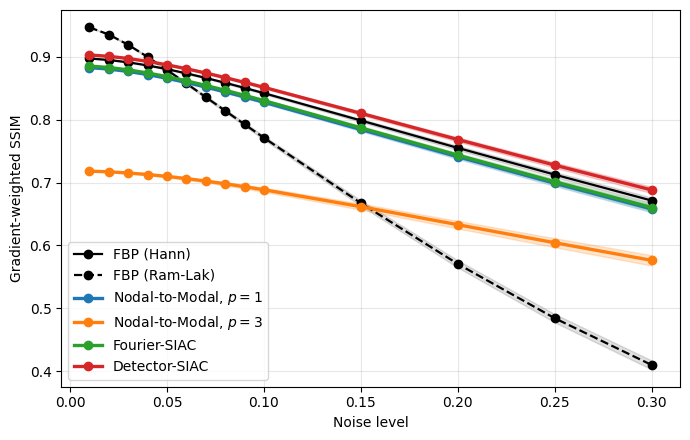

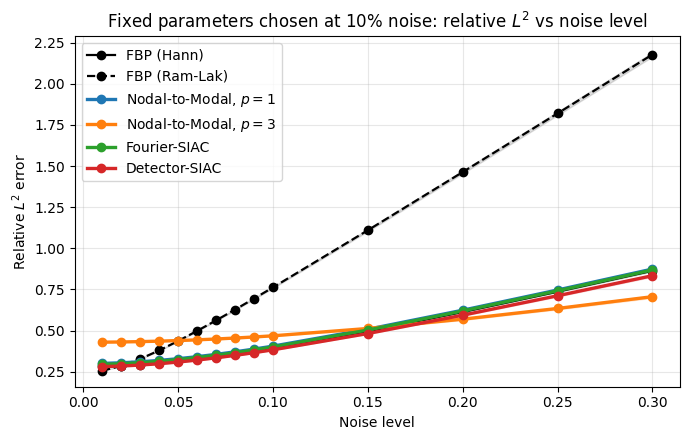

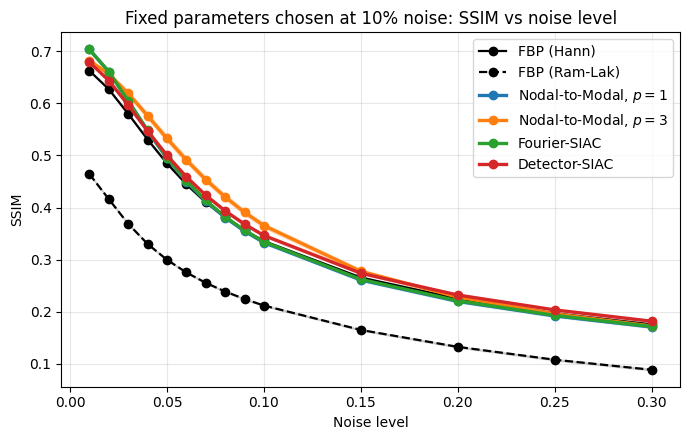

In [32]:
plot_mc_metric(
    fixed_curves_10_masked,
    metric="gw_ssim",
    # title="Fixed parameters chosen at 10% noise: gradient-weighted SSIM vs noise level",
    method_col="method_variant",
    ylabel="Gradient-weighted SSIM",
    style_cols=[],
    save_path="figures/MC_fixedparams_gwssim_vs_noise.pdf"
)

plot_mc_metric(
    fixed_curves_10_masked,
    metric="rel_l2_err",
    title="Fixed parameters chosen at 10% noise: relative $L^2$ vs noise level",
    method_col="method_variant",
    ylabel="Relative $L^2$ error",
    style_cols=[],
)


plot_mc_metric(
    fixed_curves_10_masked,
    metric="ssim",
    title="Fixed parameters chosen at 10% noise: SSIM vs noise level",
    method_col="method_variant",
    ylabel="SSIM",
    style_cols=[],
)

(<Figure size 700x450 with 1 Axes>,
 <Axes: xlabel='Noise level', ylabel='Gradient-weighted SSIM'>)

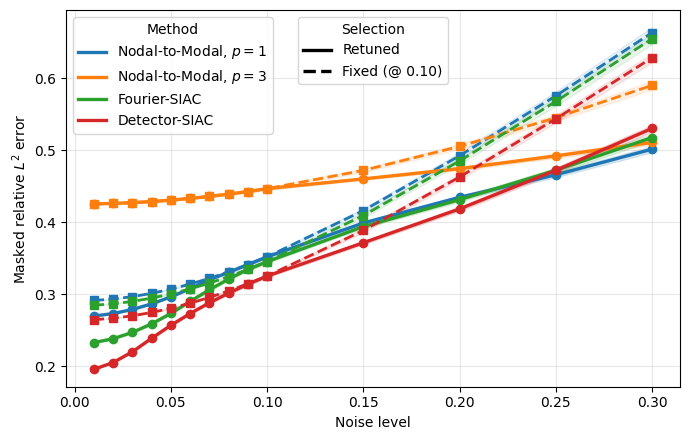

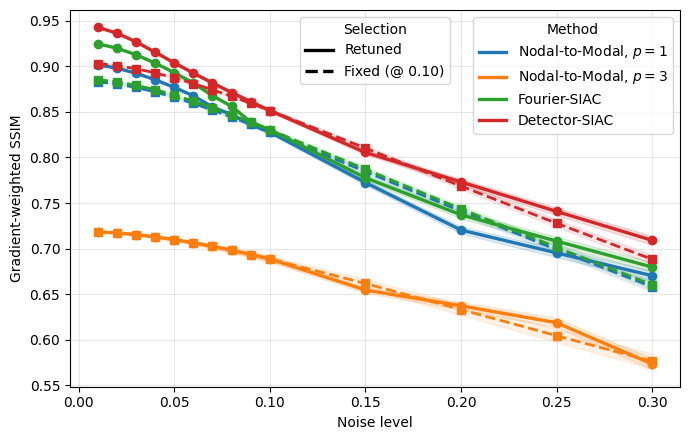

In [33]:
compare_fixed_vs_retuned(
    retuned_df=best_masked_rel_l2,
    fixed_df=fixed_curves_10_masked,
    metric="masked_rel_l2_err",
    method_col="method_variant",
    title="Retuned vs fixed parameters (chosen at 10% noise)",
    ylabel="Masked relative $L^2$ error",
    save_path="figures/MC_fixedparams_vs_retuned_masked_l2_vs_noise.pdf", 
    legend_places = ["upper center", "upper left"]
)

compare_fixed_vs_retuned(
    retuned_df=best_masked_rel_l2,
    fixed_df=fixed_curves_10_masked,
    metric="gw_ssim",
    method_col="method_variant",
    title="Retuned vs fixed parameters (chosen at 10% noise)",
    ylabel="Gradient-weighted SSIM",
    save_path="figures/MC_fixedparams_vs_retuned_gw_ssim_vs_noise.pdf", 
    legend_places = ["upper center", "upper right"]
)

In [34]:
metrics = [
    "masked_rel_l2_err_mean",
    "gw_ssim_mean",
    "rel_l2_err_mean",
    "ssim_mean"
]

def extract(df, family, method, noise_level, p=None, moments=None, BSorder=None):
    mask = (
        (df["family"] == family) &
        (df["method"] == method) &
        (df["noise_level"] == noise_level)
    )

    if p is not None:
        mask &= df["p"] == p
    if moments is not None:
        mask &= df["moments"] == moments
    if BSorder is not None:
        mask &= df["BSorder"] == BSorder

    return df.loc[mask, metrics]

noise_level = 0.1

res1 = extract(
    summary_all,
    family="SIAC",
    method="post_recon_dg_siac",
    noise_level=noise_level,
    p=1.0,
    moments=5.0,
    BSorder=1.0
)

res2 = extract(
    summary_all,
    family="SIAC",
    method="post_recon_fourier_siac",
    noise_level=noise_level,
    moments=3.0,
    BSorder=10.0
)

res3 = extract(
    summary_all,
    family="SIAC",
    method="pre_recon_detector_siac",
    noise_level=noise_level,
    moments=5.0,
    BSorder=13.0
)

res4 = extract(
    summary_all,
    family="FBP",
    method="fbp_hann",
    noise_level=noise_level,
)

res5 = extract(
    summary_all,
    family="FBP",
    method="fbp_ramlak",
    noise_level=noise_level,
)

for name, res in zip(
    ["DG-SIAC", "Fourier-SIAC (post)", "Fourier-SIAC (pre)", "FBP Hann", "FBP Ram-Lak"],
    [res1, res2, res3, res4, res5]
):
    print(f"\n{name}:\n", res)


DG-SIAC:
      masked_rel_l2_err_mean  gw_ssim_mean  rel_l2_err_mean  ssim_mean
168                0.364293      0.826381         0.439979   0.300033

Fourier-SIAC (post):
      masked_rel_l2_err_mean  gw_ssim_mean  rel_l2_err_mean  ssim_mean
745                0.345094      0.830484         0.400242   0.334164

Fourier-SIAC (pre):
       masked_rel_l2_err_mean  gw_ssim_mean  rel_l2_err_mean  ssim_mean
1419                0.344784      0.848724         0.443881   0.294366

FBP Hann:
    masked_rel_l2_err_mean  gw_ssim_mean  rel_l2_err_mean  ssim_mean
9                0.330589      0.842359         0.391056   0.335572

FBP Ram-Lak:
     masked_rel_l2_err_mean  gw_ssim_mean  rel_l2_err_mean  ssim_mean
23                0.551655      0.771289          0.76214   0.211909
